# SNA Analysis: Instagram Social Network (2 Layer)

- `user_with_comment_in_post.csv` → edge table (commenter → post_owner)
- `user_comments_received.csv`    → in-degree proxy per post owner
- `post_comment_rank.csv`         → post-level comment rank
- `dataset_clean.csv`             → raw dataset untuk node attributes

---

## Edge Architecture

```
PRIMARY  →  comment-on-post
            commenter_username → post_owner_username
            weight = comment_count (0.4) + total_like (0.2) + total_interactions (0.4)

LAYER 2  →  mention

SKIP     →  co-keyword sebagai edge (terlalu noisy)
            → disimpan sebagai node attribute active_keywords
```

## Centrality yang dihitung

| Metric | Interpretasi Bisnis |
|---|---|
| **In-degree** | Berapa unique commenter datang ke akun ini → popularitas |
| **PageRank** | Engagement yang datang ke suatu node → directed graph  |
| **Betweenness** | Jembatan antar komunitas → paling valuable untuk brand outreach |
| **Out-degree** | Seberapa aktif akun ini komentar ke akun lain  → dipakai untuk: cari buzzer, hub detection (node yang menyebarkan interaksi), community engager (akun yang connect ke banyak orang) |
| **Authority (HITS)** | Hub (tinggi) → akun yang sering engage ke akun penting & authority (tinggi) → akun yang sering dikomentari / dimention oleh akun penting  |
| **Eigenvector** | Node dianggap penting kalau dia terhubung ke node penting lainnya “temenan sama orang terkenal bikin lu ikut penting” → undirected graph |

## Pipeline
1. Install & Import
2. Load Data & Validasi
3. Build Network Graph
4. Network Overview Statistics
5. Centrality Metrics Computation
6. Influencer Tier Ranking
7. Community Detection (Louvain)
8. White Space Analysis
9. Export untuk Backend API


---
## 0. Install & Import

In [1]:
# ── Install dependencies (jalankan sekali) ─────────────────────────────────
!pip install networkx python-louvain pyvis pandas numpy matplotlib seaborn scipy -q


[notice] A new release of pip is available: 24.0 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns
import json
import warnings
from collections import Counter
from pyvis.network import Network
import community as community_louvain

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 120

print('✅ Libraries loaded')

✅ Libraries loaded


In [3]:
# ── Configuration ──────────────────────────────────────────────────────────

# Core Weight Parameters (layer 1: comment based)
COMMENT_WEIGHT              = 0.4   # Base weight untuk setiap comment edge
INTERACTION_WEIGHT_BOOST    = 0.4   # Boost jika ada reply
LIKE_WEIGHT_BOOST           = 0.2   # Boost dari total like

# Scaling Method
USE_LOG_SCALE               = True   # Gunakan log(1+x) untuk interaction & like

# Edge Filtering
MIN_EDGE_WEIGHT             = 0.5      # Filter edges di bawah threshold (karena pakai log scale, bisa 0 untuk tetap mempertahankan semua edge)

# Visualization
TOP_N_NODES_VIZ             = 500    # Limit node untuk Pyvis (performa)

# Centrality
PAGERANK_ALPHA              = 0.85

# Community Detection
LOUVAIN_RESOLUTION          = 1.0
LOUVAIN_RANDOM_STATE        = 42

print("✅ Config set (mention + interaction + like weighting)")

✅ Config set (mention + interaction + like weighting)


---
## 1. Load Data & Validasi

In [4]:
# ── Load raw dataset ───────────────────────────────────────────────────────
df = pd.read_csv('../data/processed/dataset_final_clean_revised.csv', low_memory=False)
print(f'Raw dataset        : {df.shape}')
print(f'Columns            : {list(df.columns)}')

Raw dataset        : (2215, 20)
Columns            : ['date', 'keyword', 'url', 'content', 'username', 'total_like', 'total_interaction', 'content_processed', 'sentiment_label', 'sentiment_score', 'post_id', 'comment_id', 'is_comment', 'year_month', 'day_of_week', 'hour', 'mentions', 'hashtags', 'n_mentions', 'n_hashtags']


In [5]:
# Cek format kolom mentions
print(df['mentions'].dtype)
print("\nSample values (10 baris pertama):")
print(df['mentions'].head(10).tolist())

print("\nValue counts non-null:")
print(df['mentions'].notna().sum(), "non-null rows")
print(df['mentions'].isna().sum(), "null rows")

# Cek baris yang BUKAN null dan BUKAN string kosong
mask = df['mentions'].notna() & (df['mentions'].astype(str).str.strip() != '') & (df['mentions'].astype(str).str.strip() != '[]')
print(f"\nBaris yang kelihatannya punya mention: {mask.sum()}")
print("\nContoh isinya:")
print(df.loc[mask, 'mentions'].head(5).tolist())

object

Sample values (10 baris pertama):
[nan, nan, nan, nan, nan, nan, nan, nan, nan, nan]

Value counts non-null:
84 non-null rows
2131 null rows

Baris yang kelihatannya punya mention: 84

Contoh isinya:
['mancingsaham', 'bloombergtechnoz', 'milenianews', 'bloombergtechnoz', 'infoterkinimu']


In [6]:
# Cek rows yang kemungkinan multi-mention
mask = df['mentions'].notna() & (df['mentions'].astype(str).str.strip() != '')
sample = df.loc[mask, ['username', 'mentions', 'n_mentions']].head(20)
print(sample.to_string())

              username                                       mentions  n_mentions
19        mancingsaham                                   mancingsaham           1
29    bloombergtechnoz                               bloombergtechnoz           1
44         milenianews                                    milenianews           1
65    bloombergtechnoz                               bloombergtechnoz           1
68       infoterkinimu                                  infoterkinimu           1
101       friedo.hekya        gerindra|prabowo|rizky_irmansyah|tumgrd           4
108  topik.sumbar24jam                                        metrotv           1
109      arafatsaid765                                        sorotan           1
112          aan101425                                        prabowo           1
173     mg.mampang_nur                                      matanajwa           1
179        cerita.rame  bahlillahadalia|prabowo|purbayayudhi.official           3
235            a

In [7]:
import ast
import re

def parse_mentions(val):
    if pd.isna(val) or str(val).strip() in ('', '[]', 'nan'):
        return []
    
    s = str(val).strip()
    
    # Format list: ["a", "b"]
    if s.startswith('['):
        try:
            result = ast.literal_eval(s)
            return [str(x).strip() for x in result if str(x).strip()]
        except Exception:
            pass
    
    # ✅ Format pipe-separated: "a|b|c"
    mentions = [m.strip().lstrip('@') for m in s.split('|') if m.strip()]
    return mentions

# Apply ulang
df['mentions_parsed'] = df['mentions'].apply(parse_mentions)
df['n_mentions_calc']  = df['mentions_parsed'].apply(len)

# ── Explode → edge rows ────────────────────────────────────────────────────
df_mention  = df[df['n_mentions_calc'] > 0][['username', 'mentions_parsed']].copy()
df_exploded = df_mention.explode('mentions_parsed').rename(
    columns={'username': 'source', 'mentions_parsed': 'target'}
)
df_exploded = df_exploded[
    df_exploded['target'].notna() &
    (df_exploded['target'].astype(str).str.strip() != '') &
    (df_exploded['source'] != df_exploded['target'])
]

# ── Summary ────────────────────────────────────────────────────────────────
print("=" * 52)
print("  Dataset split:")
print(f"    Total rows (posts + comments): {len(df):,}")
print(f"    Posts   (is_comment=False)   : {(df['is_comment']==False).sum():,}")
print(f"    Comments (is_comment=True)   : {(df['is_comment']==True).sum():,}")
print(f"    Rows with mentions           : {(df['n_mentions_calc'] > 0).sum():,}")
print(f"    Edge rows (after explode)    : {len(df_exploded):,}")
print(f"    Unique source nodes          : {df_exploded['source'].nunique():,}")
print(f"    Unique target nodes          : {df_exploded['target'].nunique():,}")
print("=" * 52)

  Dataset split:
    Total rows (posts + comments): 2,215
    Posts   (is_comment=False)   : 1,346
    Comments (is_comment=True)   : 869
    Rows with mentions           : 84
    Edge rows (after explode)    : 106
    Unique source nodes          : 56
    Unique target nodes          : 78


In [8]:
# Buat versi RAW dulu (tanpa filter apapun)
df_mention = df[df['n_mentions_calc'] > 0][['username', 'mentions_parsed']].copy()

df_exploded_raw = df_mention.explode('mentions_parsed').rename(
    columns={'username': 'source', 'mentions_parsed': 'target'}
)
df_exploded_raw = df_exploded_raw[
    df_exploded_raw['target'].notna() &
    (df_exploded_raw['target'].astype(str).str.strip() != '')
]

# Cek self-loop
self_loop = df_exploded_raw[df_exploded_raw['source'] == df_exploded_raw['target']]
print(f"Self-loop rows   : {len(self_loop)}")
print(self_loop[['source', 'target']].to_string())

# Cek duplicate rows
dup = df[df['mentions'].notna()].duplicated(subset=['username', 'mentions']).sum()
print(f"\nDuplicate rows   : {dup}")

# Bandingkan
print(f"\nRaw edge rows            : {len(df_exploded_raw)}")
print(f"Setelah filter self-loop : {len(df_exploded_raw[df_exploded_raw['source'] != df_exploded_raw['target']])}")

Self-loop rows   : 23
                  source              target
19          mancingsaham        mancingsaham
29      bloombergtechnoz    bloombergtechnoz
44           milenianews         milenianews
65      bloombergtechnoz    bloombergtechnoz
68         infoterkinimu       infoterkinimu
235              asep19_             asep19_
394            kompascom           kompascom
446          officialicm         officialicm
604            dumpjarea           dumpjarea
674      heraldsulselbar     heraldsulselbar
809            aktualcom           aktualcom
972         waspadadotid        waspadadotid
1142    bloombergtechnoz    bloombergtechnoz
1541         likecirebon         likecirebon
1615          periklindo          periklindo
1696  sankelux_sankeindo  sankelux_sankeindo
1698           beldocuan           beldocuan
1711        cekberitanya        cekberitanya
1744     reformsyndicate     reformsyndicate
1765          lifeatgenb          lifeatgenb
1928   ditlitka.ppidunia   ditlit

In [9]:
df_has_mention = df[df['mentions'].notna()].copy()
dup_mask = df_has_mention.duplicated(subset=['username', 'mentions'], keep=False)
df_dups = df_has_mention[dup_mask].sort_values(['username', 'mentions'])

print(f"Total baris duplikat : {len(df_dups)}")
print(f"Unique pasangan      : {df_dups.groupby(['username','mentions']).ngroups}")
print()

for (uname, mention), grp in df_dups.groupby(['username', 'mentions']):
    print(f"{'='*60}")
    print(f"username : {uname}")
    print(f"mentions : {mention}")
    print(f"Jumlah duplikat : {len(grp)} baris (index: {grp.index.tolist()})")
    print()

    same_cols, diff_cols = [], []

    for col in grp.columns:
        try:
            # Convert ke string dulu untuk handle kolom berisi list
            n_unique = grp[col].astype(str).nunique()
        except Exception:
            n_unique = 2  # anggap beda kalau gagal
        
        if n_unique == 1:
            same_cols.append(col)
        else:
            diff_cols.append(col)

    print(f"✅ Kolom SAMA ({len(same_cols)}) : {same_cols}")
    print(f"❌ Kolom BEDA ({len(diff_cols)}) : {diff_cols}")

    if diff_cols:
        print("\nDetail kolom yang beda:")
        # Exclude list-type columns dari display langsung
        safe_diff = [c for c in diff_cols if grp[c].apply(lambda x: not isinstance(x, list)).all()]
        if safe_diff:
            print(grp[safe_diff].to_string())
    print()

Total baris duplikat : 7
Unique pasangan      : 3

username : 350id
mentions : bahlillahadalia|prabowo
Jumlah duplikat : 2 baris (index: [433, 434])

✅ Kolom SAMA (21) : ['date', 'url', 'content', 'username', 'total_like', 'total_interaction', 'content_processed', 'sentiment_label', 'sentiment_score', 'post_id', 'comment_id', 'is_comment', 'year_month', 'day_of_week', 'hour', 'mentions', 'hashtags', 'n_mentions', 'n_hashtags', 'mentions_parsed', 'n_mentions_calc']
❌ Kolom BEDA (1) : ['keyword']

Detail kolom yang beda:
          keyword
433    SubsidiBBM
434  KrisisEnergi

username : bloombergtechnoz
mentions : bloombergtechnoz
Jumlah duplikat : 3 baris (index: [29, 65, 1142])

✅ Kolom SAMA (10) : ['keyword', 'username', 'total_interaction', 'sentiment_label', 'comment_id', 'is_comment', 'mentions', 'n_mentions', 'mentions_parsed', 'n_mentions_calc']
❌ Kolom BEDA (12) : ['date', 'url', 'content', 'total_like', 'content_processed', 'sentiment_score', 'post_id', 'year_month', 'day_of_wee

In [10]:
# ── Load edge table (PRIMARY input untuk SNA) ──────────────────────────────
# Kolom wajib: commenter_list, post_owner_username, comment_count
edge_df = pd.read_csv('../data/processed/post_comment_rank.csv')
print(f'Edge table shape   : {edge_df.shape}')
print(f'Columns            : {list(edge_df.columns)}')
print()
print(edge_df.head(5).to_string(index=False))

Edge table shape   : (190, 10)
Columns            : ['post_id', 'post_owner_username', 'count_post', 'comment_count', 'unique_commenters', 'total_comment_like', 'post_like', 'post_interaction', 'comment_id_list', 'commenter_list']

    post_id post_owner_username  count_post  comment_count  unique_commenters  total_comment_like  post_like  post_interaction                                                                                                                                                                                                    comment_id_list                                                                                                                                                                    commenter_list
DWub4RBAX-U        agam.munawar           1              1                  1                   0         47                 0                                                                                                                              

In [11]:
# ── Validasi kolom wajib ───────────────────────────────────────────────────
REQUIRED = {'commenter_list', 'post_owner_username', 'comment_count'}
missing  = REQUIRED - set(edge_df.columns)
if missing:
    raise ValueError(
        f'❌ Kolom tidak ditemukan: {missing}\n'
        f'   Pastikan output EDA memiliki kolom: {REQUIRED}'
    )
print('✅ Kolom edge valid')
print(f'   Unique commenters  : {edge_df["commenter_list"].nunique():,}')
print(f'   Unique post owners : {edge_df["post_owner_username"].nunique():,}')
print(f'   comment_count range: {edge_df["comment_count"].min()} – {edge_df["comment_count"].max()}')

✅ Kolom edge valid
   Unique commenters  : 189
   Unique post owners : 123
   comment_count range: 1 – 10


In [12]:
# ── Load comments_received (in-degree proxy) ───────────────────────────────
comments_received = pd.read_csv('../data/processed/user_comments_received.csv')
print(f'comments_received shape : {comments_received.shape}')
print(comments_received.head(10).to_string(index=False))

comments_received shape : (123, 2)
          username  total_comments_received
         sindonews                       79
moltensalt.insight                       42
        otoproject                       39
       bitorexpost                       38
           metrotv                       30
       luarbioskop                       29
  koranbaliexpress                       26
   investordailyid                       20
         kompascom                       20
 sukabumiupdatecom                       19


In [13]:
# ── Load mention edges (LAYER 2) ─────────────────────────────────
edges_mention = pd.DataFrame()
try:
    edges_mention = pd.read_csv('../data/processed/edges_mention_revised.csv')
    print(f'✅ Mention edges : {len(edges_mention):,} rows')
except FileNotFoundError:
    print('⚠️  edges_mention.csv tidak ditemukan — mention layer di-skip')

# ── Load keyword data untuk node attribute ──────────────────────────────────
user_keywords = {}
if 'username' in df.columns and 'keyword' in df.columns:
    for user, grp in df.groupby('username')['keyword']:
        user_keywords[user] = list(grp.dropna().unique())
    print(f'✅ Keyword node attributes : {len(user_keywords):,} users')
else:
    print('⚠️  Keyword data tidak tersedia')

✅ Mention edges : 106 rows
✅ Keyword node attributes : 1,642 users


In [14]:
# ── Load comment engagement edges (interaction + like) ─────────────────────

edges_comment = pd.DataFrame()

try:
    edges_comment = pd.read_csv('../data/processed/reply_like_comment.csv')

    print(f'✅ Comment edges : {len(edges_comment):,} rows')

    # Ensure numeric types (penting untuk weighting)

    for col in ["total_interaction", "total_like"]:

        if col in edges_comment.columns:
            edges_comment[col] = (
                edges_comment[col]
                .fillna(0)
                .astype(int)
            )

        else:
            print(f'⚠️  Column {col} tidak ditemukan')

except FileNotFoundError:

    print(
        '⚠️  reply_like_comment.csv tidak ditemukan — comment layer di-skip'
    )

✅ Comment edges : 887 rows


---
## 2. Build Network Graph
- Layer 1 (comment => engagement)
- Node = username (post owner maupun commenter)
- Edge = commenter → post_owner, weight = comment_count + total_like + total_interaction


In [15]:
# ── Filter hanya comment ───────────────────────────────────

df_comment = df[df["is_comment"] == True].copy()

# Pastikan tidak ada null penting
df_comment = df_comment[
    df_comment["comment_id"].notna()
].copy()

print("Total comments:", len(df_comment))

Total comments: 869


In [16]:
# ── Ambil post owner dari post rows ───────────────────────

df_post_owner = (
    df[df["is_comment"] == False]
    [["post_id", "username"]]
    .rename(columns={"username": "post_owner"})
)

In [17]:
df_comment = df_comment.merge(
    df_post_owner,
    on="post_id",
    how="left"
)

# Rename biar jelas
df_comment["source"] = df_comment["username"]
df_comment["target"] = df_comment["post_owner"]

In [18]:
# clean engagement

for col in ["total_like", "total_interaction"]:
    df_comment[col] = (
        df_comment[col]
        .fillna(0)
        .astype(float)
    )

In [19]:
# hitung weight

if USE_LOG_SCALE:

    like_component = np.log1p(df_comment["total_like"])
    interaction_component = np.log1p(df_comment["total_interaction"])

else:

    like_component = df_comment["total_like"]
    interaction_component = df_comment["total_interaction"]

df_comment["weight"] = (
    1
    + LIKE_WEIGHT_BOOST * like_component
    + INTERACTION_WEIGHT_BOOST * interaction_component
)

In [20]:
# remove self-loop (commenter yang komentar di postingan sendiri)
# kalau tidak dihapus, akan banyak sekali self-loop yang bisa mendominasi graph (karena banyak yang komentar di postingan sendiri)
df_comment = df_comment[
    df_comment["source"] != df_comment["target"]
]

##### Build Graph - Layer 1

In [21]:
# build graph

import networkx as nx

G_comment = nx.DiGraph()

for _, r in df_comment.iterrows():
    G_comment.add_edge(
        r["source"],
        r["target"],
        weight=r["weight"]
    )

print("✅ G_comment built")
print("Nodes:", G_comment.number_of_nodes())
print("Edges:", G_comment.number_of_edges())

✅ G_comment built
Nodes: 931
Edges: 823


In [22]:
top_nodes = sorted(
    G_comment.degree,
    key=lambda x: x[1],
    reverse=True
)[:2]

top_nodes = [n for n, _ in top_nodes]

# ambil neighbors juga
expanded_nodes = set(top_nodes)

for n in top_nodes:
    expanded_nodes.update(G_comment.successors(n))
    expanded_nodes.update(G_comment.predecessors(n))

G_sub = G_comment.subgraph(expanded_nodes)

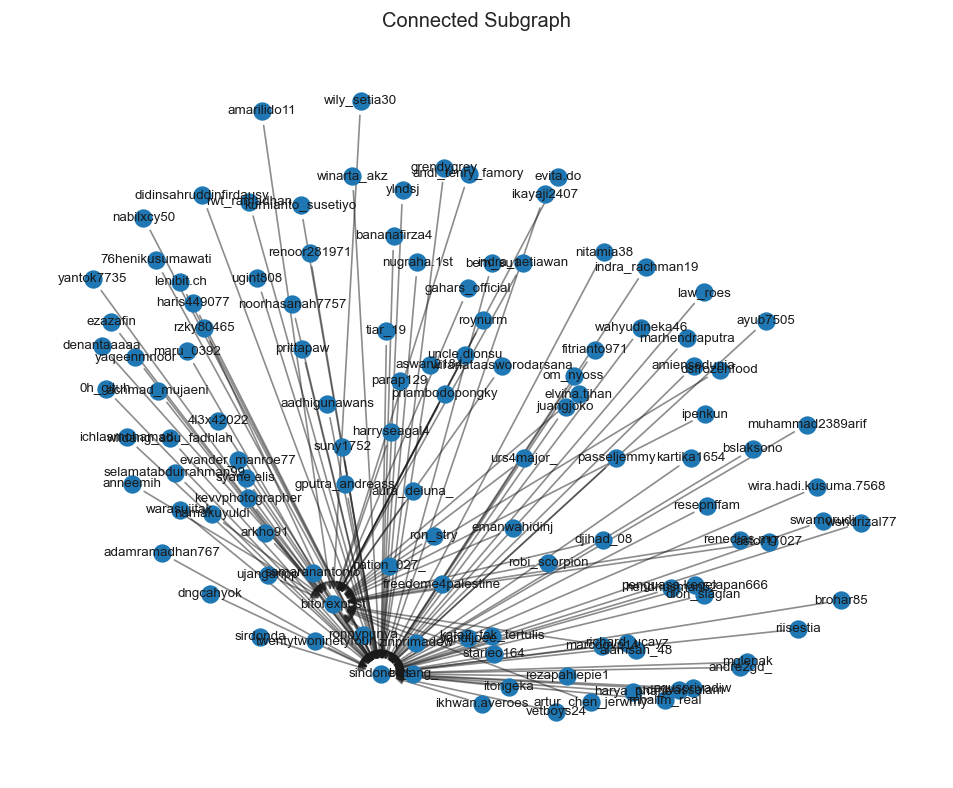

In [23]:
plt.figure(figsize=(10, 8))

pos = nx.spring_layout(G_sub, k=0.5)

nx.draw_networkx_nodes(G_sub, pos, node_size=100)
nx.draw_networkx_edges(G_sub, pos, alpha=0.5)
nx.draw_networkx_labels(G_sub, pos, font_size=8)

plt.title("Connected Subgraph")
plt.axis("off")
plt.show()

In [24]:
# PageRank = ukuran influence paling kuat di network 
# tujuan: mempertimbangkan struktur network, mempertimbangkan weight, tidak bias ke spam
# influence = sum(weight × influence dari node lain)

pr_comment = nx.pagerank(
    G_comment,
    alpha=PAGERANK_ALPHA,
    weight="weight"
)

In [25]:
sorted(pr_comment.items(), key=lambda x: x[1], reverse=True)[:10]

[('sindonews', 0.04084841277751503),
 ('bitorexpost', 0.020593219355969243),
 ('otoproject', 0.020229477016823406),
 ('metrotv', 0.016387888208637482),
 ('luarbioskop', 0.01586222181522101),
 ('koranbaliexpress', 0.013233889848138664),
 ('kompascom', 0.011131224274472785),
 ('sukabumiupdatecom', 0.010605557881056315),
 ('moltensalt.insight', 0.010079891487639844),
 ('investordailyid', 0.010058965557206494)]

##### Comparing pagerank vs in-degree

In [26]:
df_compare = pd.DataFrame({
    "username": list(pr_comment.keys()),
    "pagerank": list(pr_comment.values())
})

# tambahkan in-degree
df_compare["in_degree"] = df_compare["username"].map(
    dict(G_comment.in_degree())
).fillna(0)

In [27]:
# Top PageRank
top_pr = df_compare.sort_values("pagerank", ascending=False).head(10)

# Top In-degree
top_in = df_compare.sort_values("in_degree", ascending=False).head(10)

print("=== Top PageRank (Influence) ===")
print(top_pr.to_string(index=False))

print("\n=== Top In-degree (Popularity) ===")
print(top_in.to_string(index=False))

=== Top PageRank (Influence) ===
          username  pagerank  in_degree
         sindonews  0.040848         78
       bitorexpost  0.020593         38
        otoproject  0.020229         38
           metrotv  0.016388         30
       luarbioskop  0.015862         29
  koranbaliexpress  0.013234         24
         kompascom  0.011131         20
 sukabumiupdatecom  0.010606         19
moltensalt.insight  0.010080         18
   investordailyid  0.010059         19

=== Top In-degree (Popularity) ===
          username  pagerank  in_degree
         sindonews  0.040848         78
       bitorexpost  0.020593         38
        otoproject  0.020229         38
           metrotv  0.016388         30
       luarbioskop  0.015862         29
  koranbaliexpress  0.013234         24
         kompascom  0.011131         20
 sukabumiupdatecom  0.010606         19
   investordailyid  0.010059         19
moltensalt.insight  0.010080         18


In [28]:
df_compare["rank_pr"] = df_compare["pagerank"].rank(ascending=False)
df_compare["rank_in"] = df_compare["in_degree"].rank(ascending=False)

df_compare["rank_gap"] = df_compare["rank_in"] - df_compare["rank_pr"]

In [29]:
# ✔ sedikit yang connect, ✔ tapi yang connect berkualitas tinggi
# rank_gap positif = lebih tinggi di PageRank daripada in-degree (influence > popularity)

df_compare.sort_values("rank_gap", ascending=False).head(10)

,username,pagerank,in_degree,rank_pr,rank_in,rank_gap
449,syamsiro,0.001669,2,77.0,80.0,3.0
423,mkiofficial_,0.001669,2,77.0,80.0,3.0
500,rimbasatwa.id,0.001669,2,77.0,80.0,3.0
215,otospector,0.001669,2,77.0,80.0,3.0
200,ariusama20,0.001669,2,77.0,80.0,3.0
187,tribunnews,0.001669,2,77.0,80.0,3.0
534,anggadrumaholic,0.001669,2,77.0,80.0,3.0
895,jakarta_headlines,0.001669,2,77.0,80.0,3.0
897,kabarciledug,0.001669,2,77.0,80.0,3.0
733,kabartanpadelay,0.001669,2,77.0,80.0,3.0


In [30]:
# banyak yang connect, tapi kurang berkualitas (spammy)
df_compare.sort_values("rank_gap").head(10)

,username,pagerank,in_degree,rank_pr,rank_in,rank_gap
725,pln.epi,0.001582,3,84.0,68.0,-16.0
454,officialinewstv,0.005456,10,34.0,25.0,-9.0
290,puspenpol,0.001238,2,88.0,80.0,-8.0
440,laporan8.id,0.005485,10,33.0,25.0,-8.0
641,indo.flashid,0.002289,4,64.0,56.5,-7.5
213,autotivo,0.001308,2,87.0,80.0,-7.0
624,webekspor,0.005616,10,32.0,25.0,-7.0
743,wartaekonomi,0.002370,4,63.0,56.5,-6.5
45,daripresiden,0.005704,10,31.0,25.0,-6.0
217,vivacoid,0.001389,2,86.0,80.0,-6.0


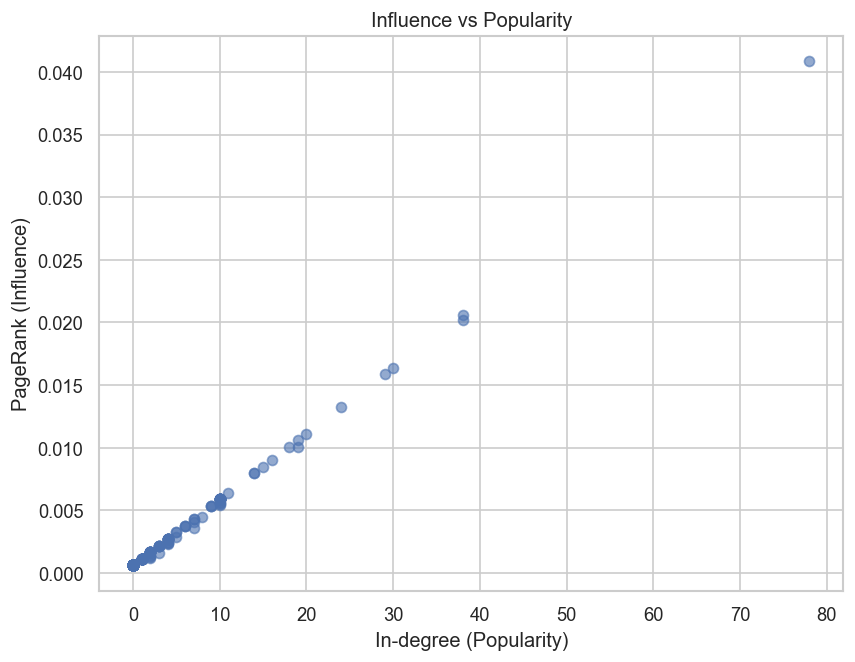

In [31]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(
    df_compare["in_degree"],
    df_compare["pagerank"],
    alpha=0.6
)

plt.xlabel("In-degree (Popularity)")
plt.ylabel("PageRank (Influence)")
plt.title("Influence vs Popularity")

plt.grid(True)
plt.show()

#### Build Graph - Layer 2 - Mentioned Network (discourse/attention)

In [32]:
# build mention graph

import networkx as nx
import pandas as pd

G_mention = nx.DiGraph()

if len(edges_mention) > 0:

    src_col = next((c for c in ['mentioner','source','from','username']
                    if c in edges_mention.columns), None)

    tgt_col = next((c for c in ['mentioned','target','to','mentioned_username']
                    if c in edges_mention.columns), None)

    if src_col and tgt_col:

        mention_pairs = (
            edges_mention[[src_col, tgt_col]]
            .rename(columns={src_col: 'source', tgt_col: 'target'})
        )

        mention_pairs = mention_pairs[
            mention_pairs["source"] != mention_pairs["target"]
        ]

        # hitung frekuensi mention
        mention_counts = (
            mention_pairs
            .value_counts()
            .reset_index(name="weight")
        )

        for _, r in mention_counts.iterrows():
            G_mention.add_edge(
                r["source"],
                r["target"],
                weight=r["weight"]
            )

print("✅ G_mention built")
print("Nodes:", G_mention.number_of_nodes())
print("Edges:", G_mention.number_of_edges())

✅ G_mention built
Nodes: 145
Edges: 106


##### Visual (ego-network)

In [33]:
target = "prabowo"  # ganti sesuai akun yang mau dilihat

neighbors = list(G_mention.predecessors(target)) + list(G_mention.successors(target))
ego_nodes = set(neighbors + [target])

G_sub = G_mention.subgraph(ego_nodes)

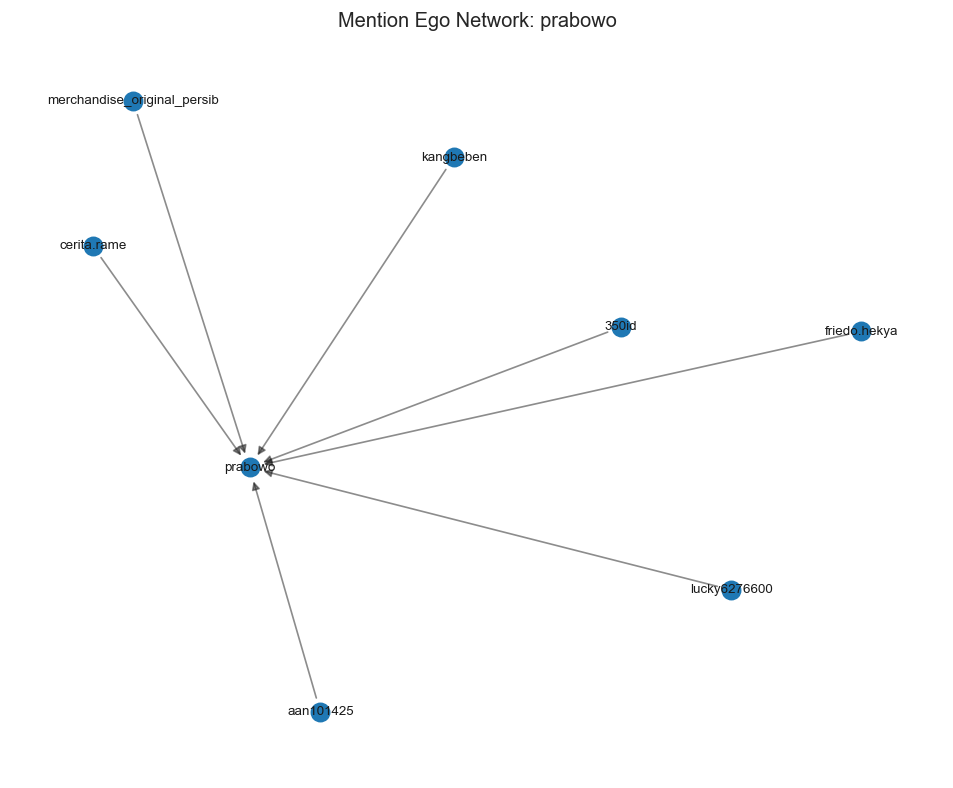

In [34]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))
pos = nx.spring_layout(G_sub, k=0.5)

nx.draw_networkx_nodes(G_sub, pos, node_size=120)
nx.draw_networkx_edges(G_sub, pos, alpha=0.5)
nx.draw_networkx_labels(G_sub, pos, font_size=8)

plt.title(f"Mention Ego Network: {target}")
plt.axis("off")
plt.show()

##### Top-mentions edges

In [35]:
top_edges = sorted(
    G_mention.edges(data=True),
    key=lambda x: x[2]["weight"],
    reverse=True
)[:50]

G_sub = nx.DiGraph()
G_sub.add_edges_from(top_edges)

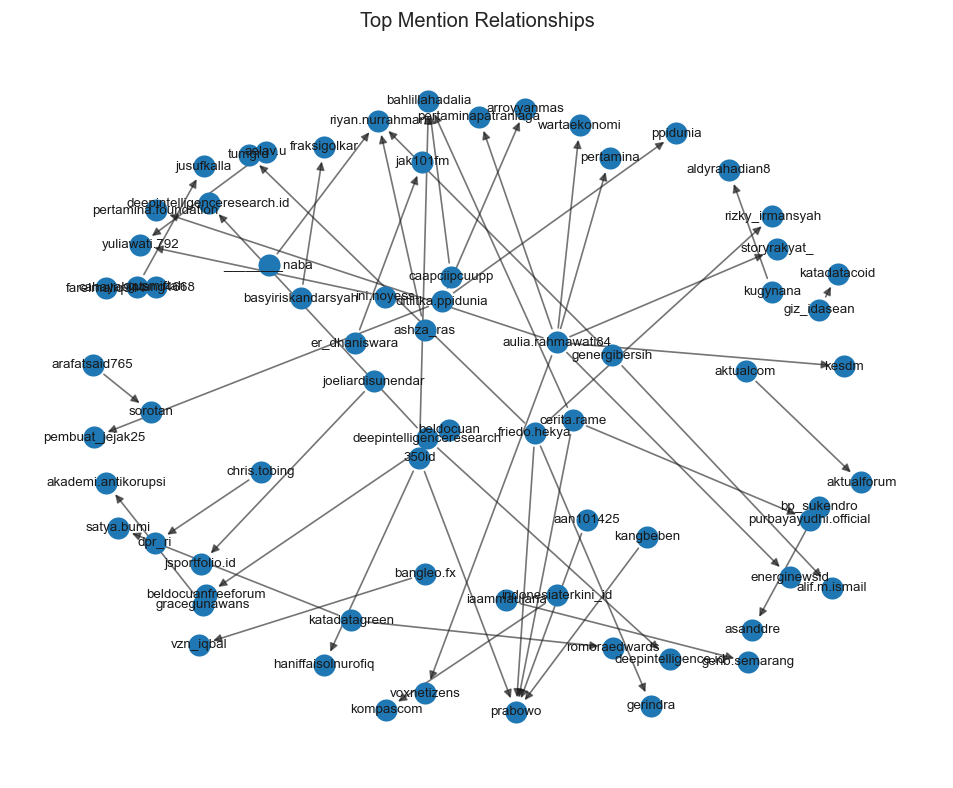

In [36]:
plt.figure(figsize=(10, 8))
pos = nx.spring_layout(G_sub, k=0.5)

nx.draw_networkx_nodes(G_sub, pos, node_size=150)
nx.draw_networkx_edges(G_sub, pos, alpha=0.6)
nx.draw_networkx_labels(G_sub, pos, font_size=8)

plt.title("Top Mention Relationships")
plt.axis("off")
plt.show()

#### Build Graph - Layer 3 - Combined

In [ ]:
# build combined graph

G_combined = nx.DiGraph()

# 1. copy comment edges
for u, v, d in G_comment.edges(data=True):
    G_combined.add_edge(u, v, weight=d["weight"])

# 2. add mention edges
for u, v, d in G_mention.edges(data=True):

    if G_combined.has_edge(u, v):
        # kalau sudah ada → boost
        G_combined[u][v]["weight"] *= MENTION_WEIGHT_BOOST
    else:
        # pure mention
        G_combined.add_edge(u, v, weight=MENTION_EDGE_WEIGHT)

print("✅ G_combined built")
print("Nodes:", G_combined.number_of_nodes())
print("Edges:", G_combined.number_of_edges())

NameError: name 'MENTION_EDGE_WEIGHT' is not defined

In [ ]:
# Lihat pasangan yang ada di BOTH comment dan mention (yang kena boost)

comment_edges = set(G_comment.edges())
mention_edges = set(G_mention.edges())

# Pasangan yang ada di keduanya
both = comment_edges & mention_edges

print(f"Total comment edges  : {len(comment_edges)}")
print(f"Total mention edges  : {len(mention_edges)}")
print(f"Pasangan yang overlap (kena boost) : {len(both)}")
print()

# Tampilkan detailnya
if len(both) > 0:
    print("=== Pasangan comment + mention (kena boost ×1.3) ===")
    for u, v in sorted(both):
        w_comment = G_comment[u][v]["weight"]
        w_mention = G_mention[u][v]["weight"]
        w_combined = G_combined[u][v]["weight"]
        print(f"  {u} → {v}")
        print(f"    comment weight  : {w_comment:.4f}")
        print(f"    mention weight  : {w_mention:.4f}")
        print(f"    combined weight : {w_combined:.4f}  (= comment × 0.7)")
        print()
else:
    print("Tidak ada pasangan yang overlap.")

# Pasangan yang pure mention only
pure_mention = mention_edges - comment_edges
print(f"=== Pure mention only (weight = 0.3) : {len(pure_mention)} pasangan ===")
for u, v in sorted(pure_mention):
    print(f"  {u} → {v}  (weight: {G_combined[u][v]['weight']:.4f})")

Total comment edges  : 823
Total mention edges  : 106
Pasangan yang overlap (kena boost) : 4

=== Pasangan comment + mention (kena boost ×1.3) ===
  meka007 → madiuntoday.id
    comment weight  : 1.2197
    mention weight  : 1.0000
    combined weight : 0.8538  (= comment × 0.7)

  meka007 → otoproject
    comment weight  : 1.9940
    mention weight  : 1.0000
    combined weight : 1.3958  (= comment × 0.7)

  tere616 → kompascom
    comment weight  : 2.5311
    mention weight  : 1.0000
    combined weight : 1.7718  (= comment × 0.7)

  yurikaputri067 → investordailyid
    comment weight  : 1.0000
    mention weight  : 1.0000
    combined weight : 0.7000  (= comment × 0.7)

=== Pure mention only (weight = 0.3) : 102 pasangan ===
  350id → bahlillahadalia  (weight: 0.3000)
  350id → haniffaisolnurofiq  (weight: 0.3000)
  350id → prabowo  (weight: 0.3000)
  ________naba → riyan.nurrahman  (weight: 0.3000)
  aan101425 → prabowo  (weight: 0.3000)
  aelav.u → yuliawati.792  (weight: 0.3000)


##### Hidden / discourse-driven influencer
- Cari user yang: rank di comment biasa rendah, tapi rank di combined tinggi

In [ ]:
pr_comment  = nx.pagerank(G_comment,  alpha=PAGERANK_ALPHA, weight="weight")
pr_combined = nx.pagerank(G_combined, alpha=PAGERANK_ALPHA, weight="weight")

In [ ]:
df_rank = pd.DataFrame({
    "username": list(set(pr_comment) | set(pr_combined))
})

df_rank["pr_comment"]  = df_rank["username"].map(pr_comment).fillna(0)
df_rank["pr_combined"] = df_rank["username"].map(pr_combined).fillna(0)

In [ ]:
df_rank["rank_comment"]  = df_rank["pr_comment"].rank(ascending=False)
df_rank["rank_combined"] = df_rank["pr_combined"].rank(ascending=False)

In [ ]:
df_rank["rank_gain"] = df_rank["rank_comment"] - df_rank["rank_combined"]

In [ ]:
top_risers = df_rank.sort_values("rank_gain", ascending=False).head(15)

print("🔥 Top Rising Users (Hidden Influencers):")
print(top_risers.to_string(index=False))

🔥 Top Rising Users (Hidden Influencers):
          username  pr_comment  pr_combined  rank_comment  rank_combined  rank_gain
   riyan.nurrahman         0.0     0.003049         981.0           46.0      935.0
     alif.m.ismail         0.0     0.002774         981.0           50.0      931.0
     genergiberish         0.0     0.002620         981.0           52.0      929.0
           prabowo         0.0     0.001545         981.0           75.0      906.0
     yuliawati.792         0.0     0.001538         981.0           82.0      899.0
        satya.bumi         0.0     0.001513         981.0           89.0      892.0
    jsportfolio.id         0.0     0.001465         981.0           90.0      891.0
beldocuanfreeforum         0.0     0.001054         981.0          118.0      863.0
       icmofficial         0.0     0.001054         981.0          118.0      863.0
    ratihandriyani         0.0     0.001054         981.0          118.0      863.0
       aktualforum         0.0     

##### Interpretasi:
- kuat di mention
- sering dibahas
- discourse-driven

In [ ]:
top_fallers = df_rank.sort_values("rank_gain").head(15)

print("⚠️ Users Losing Influence After Combine:")
print(top_fallers.to_string(index=False))

⚠️ Users Losing Influence After Combine:
             username  pr_comment  pr_combined  rank_comment  rank_combined  rank_gain
            bslaksono    0.000618     0.000569         527.5          615.5      -88.0
          hastutiwuri    0.000618     0.000569         527.5          615.5      -88.0
   andri_g.noviantoro    0.000618     0.000569         527.5          615.5      -88.0
penguasa.kegelapan666    0.000618     0.000569         527.5          615.5      -88.0
             syzahwa_    0.000618     0.000569         527.5          615.5      -88.0
       kosasihaditya_    0.000618     0.000569         527.5          615.5      -88.0
          sahimal5842    0.000618     0.000569         527.5          615.5      -88.0
           igpunyaani    0.000618     0.000569         527.5          615.5      -88.0
       hafidahmadf_18    0.000618     0.000569         527.5          615.5      -88.0
        rando_arsyad7    0.000618     0.000569         527.5          615.5      -88.0
  

##### Interpretasi:
- banyak comment
- tapi tidak di-mention

### Network Overview

In [ ]:
# ── Network Stats ──────────────────────────────────────────────

G_directed   = G_combined
G_undirected = G_combined.to_undirected()

N = G_directed.number_of_nodes()
E = G_directed.number_of_edges()

density = nx.density(G_directed)
avg_degree = E / N if N > 0 else 0

components = list(nx.connected_components(G_undirected))
largest_cc = max(components, key=len) if components else []
lcc_ratio = len(largest_cc) / N if N > 0 else 0

print('=' * 55)
print('  NETWORK OVERVIEW')
print('=' * 55)
print(f'  Nodes (users)        : {N:,}')
print(f'  Edges (interactions) : {E:,}')
print(f'  Density              : {density:.6f}')
print(f'  Avg degree           : {avg_degree:.2f}')
print(f'  Connected components : {len(components):,}')
print(f'  Largest CC (LCC) size: {len(largest_cc):,} ({lcc_ratio*100:.1f}% of nodes)')
print('=' * 55)

# Degree
in_degrees  = dict(G_directed.in_degree())
out_degrees = dict(G_directed.out_degree())
all_degrees = dict(G_undirected.degree())

print(f'  Avg in-degree  : {np.mean(list(in_degrees.values())):.2f}')
print(f'  Avg out-degree : {np.mean(list(out_degrees.values())):.2f}')
print(f'  Max in-degree  : {max(in_degrees.values())} (most targeted)')
print(f'  Max out-degree : {max(out_degrees.values())} (most active)')

  NETWORK OVERVIEW
  Nodes (users)        : 1,030
  Edges (interactions) : 925
  Density              : 0.000873
  Avg degree           : 0.90
  Connected components : 117
  Largest CC (LCC) size: 132 (12.8% of nodes)
  Avg in-degree  : 0.90
  Avg out-degree : 0.90
  Max in-degree  : 78 (most targeted)
  Max out-degree : 11 (most active)


##### Interpretasi: network sangat sparse, better nanti ego-network aja

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import os

def plot_degree_distribution(in_degrees, out_degrees, all_degrees, save_path=None):
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    configs = [
        (in_degrees, 'In-Degree', 'steelblue'),
        (out_degrees, 'Out-Degree', 'coral'),
        (all_degrees, 'Total Degree (Undirected)', 'mediumseagreen')
    ]

    for ax, (deg_dict, title, color) in zip(axes, configs):
        vals = list(deg_dict.values())
        vals_nonzero = [v for v in vals if v > 0]

        if len(vals_nonzero) > 0:
            log_vals = np.log1p(vals_nonzero)

            ax.hist(
                log_vals,
                bins=40,
                color=color,
                edgecolor='white',
                alpha=0.85
            )

            # Statistik tambahan (biar nggak cuma visual)
            mean_val = np.mean(vals_nonzero)
            median_val = np.median(vals_nonzero)

            ax.axvline(np.log1p(mean_val), linestyle='--', linewidth=1)
            ax.axvline(np.log1p(median_val), linestyle=':', linewidth=1)

        ax.set_title(f'{title} Distribution (log1p)')
        ax.set_xlabel('log1p(degree)')
        ax.set_ylabel('Count')
        ax.grid(alpha=0.2)

    plt.tight_layout()

    if save_path:
        os.makedirs(os.path.dirname(save_path), exist_ok=True)
        plt.savefig(save_path, bbox_inches='tight', dpi=300)

    plt.show()

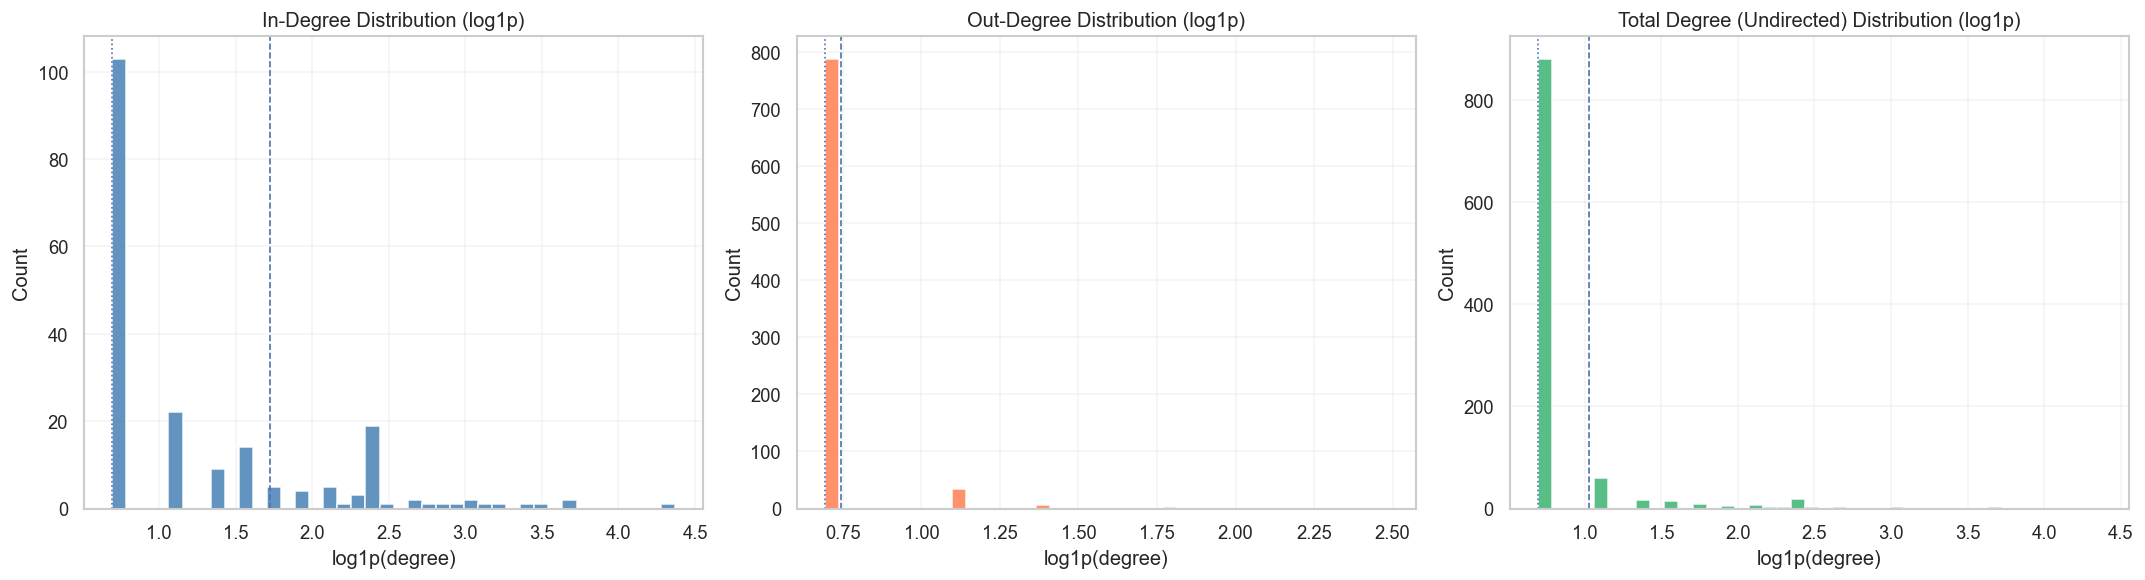

In [ ]:
plot_degree_distribution(
    in_degrees,
    out_degrees,
    all_degrees,
    save_path='../data/processed/sna_degree_dist.png'
)

#### Centrality Metrcis Computation

In [ ]:
print('Computing centrality metrics...')

# LCC
G_lcc = G_undirected.subgraph(largest_cc).copy()
G_lcc_dir = G_directed.subgraph(largest_cc).copy()

# Degree
degree_centrality = nx.degree_centrality(G_undirected)
in_degree_centrality = nx.in_degree_centrality(G_directed)
out_degree_centrality = nx.out_degree_centrality(G_directed)

# Betweenness
if N > 1000:
    betweenness = nx.betweenness_centrality(G_undirected, k=500, weight='weight')
else:
    betweenness = nx.betweenness_centrality(G_undirected, weight='weight')

# Closeness
closeness = nx.closeness_centrality(G_lcc)
closeness_full = {n: closeness.get(n, 0.0) for n in G_undirected.nodes()}

# PageRank
pagerank = nx.pagerank(G_directed, alpha=PAGERANK_ALPHA, weight='weight')

# Eigenvector
try:
    eigenvector = nx.eigenvector_centrality(G_undirected, max_iter=1000, weight='weight')
except:
    eigenvector = nx.eigenvector_centrality_numpy(G_undirected, weight='weight')

# HITS
try:
    hubs, authorities = nx.hits(G_directed, max_iter=500)
except:
    hubs = {n: 0.0 for n in G_directed.nodes()}
    authorities = {n: 0.0 for n in G_directed.nodes()}

print('✅ Centrality done')

Computing centrality metrics...
✅ Centrality done


In [ ]:
# compute centrality

# Comment centrality
pr_comment = nx.pagerank(
    G_comment,
    alpha=PAGERANK_ALPHA,
    weight="weight"
)

# Mention centrality
pr_mention = nx.pagerank(
    G_mention,
    alpha=PAGERANK_ALPHA,
    weight="weight"
)

# Combined centrality
pr_combined = nx.pagerank(
    G_combined,
    alpha=PAGERANK_ALPHA,
    weight="weight"
)

print("✅ Centrality computed")

✅ Centrality computed


In [ ]:
import pandas as pd

all_users = set(pr_comment) | set(pr_mention) | set(pr_combined)

df_centrality = pd.DataFrame({
    "user": list(all_users)
})

df_centrality["comment_centrality"] = df_centrality["user"].map(pr_comment).fillna(0)
df_centrality["mention_centrality"] = df_centrality["user"].map(pr_mention).fillna(0)
df_centrality["combined_centrality"] = df_centrality["user"].map(pr_combined).fillna(0)

df_centrality = df_centrality.sort_values(
    "combined_centrality",
    ascending=False
)

df_centrality.head(10)

,user,comment_centrality,mention_centrality,combined_centrality
411,sindonews,0.040848,0.000000,0.037645
369,bitorexpost,0.020593,0.000000,0.018866
61,otoproject,0.020229,0.007270,0.018643
746,metrotv,0.016388,0.009439,0.015587
626,luarbioskop,0.015862,0.000000,0.014370
783,koranbaliexpress,0.013234,0.000000,0.012196
635,kompascom,0.011131,0.013776,0.010743
559,sukabumiupdatecom,0.010606,0.000000,0.009774
598,moltensalt.insight,0.010080,0.000000,0.009289
996,investordailyid,0.010059,0.009439,0.009270


In [ ]:
df_centrality["role"] = "normal"

high_c = df_centrality["comment_centrality"].quantile(0.9)
high_m = df_centrality["mention_centrality"].quantile(0.9)

df_centrality.loc[
    (df_centrality["comment_centrality"] > high_c) &
    (df_centrality["mention_centrality"] > high_m),
    "role"
] = "influencer"

df_centrality.loc[
    (df_centrality["mention_centrality"] > high_m) &
    (df_centrality["comment_centrality"] < high_c),
    "role"
] = "discourse_driver"

In [ ]:
all_nodes = list(G_directed.nodes())

centrality_df = pd.DataFrame({
    'username': all_nodes,
    'pagerank': [pagerank.get(n, 0) for n in all_nodes],
    'betweenness': [betweenness.get(n, 0) for n in all_nodes],
    'degree': [degree_centrality.get(n, 0) for n in all_nodes],
    'in_degree': [G_directed.in_degree(n) for n in all_nodes],
    'out_degree': [G_directed.out_degree(n) for n in all_nodes],
    'authority': [authorities.get(n, 0) for n in all_nodes],
    'eigenvector': [eigenvector.get(n, 0) for n in all_nodes],
})

In [ ]:
centrality_df = pd.DataFrame({
    'username': all_nodes,

    # Core influence
    'pagerank': [pagerank.get(n, 0) for n in all_nodes],
    'eigenvector': [eigenvector.get(n, 0) for n in all_nodes],

    # Structure role
    'betweenness': [betweenness.get(n, 0) for n in all_nodes],
    'closeness': [closeness_full.get(n, 0) for n in all_nodes],

    # Activity
    'in_degree': [G_directed.in_degree(n) for n in all_nodes],
    'out_degree': [G_directed.out_degree(n) for n in all_nodes],

    # Authority system
    'authority': [authorities.get(n, 0) for n in all_nodes],
    'hub': [hubs.get(n, 0) for n in all_nodes],
})

In [ ]:
# Top 10 influencer (PageRank)
centrality_df.sort_values('pagerank', ascending=False).head(10)

# Top bridge (Betweenness)
centrality_df.sort_values('betweenness', ascending=False).head(10)

# Paling sering disebut (In-degree)
centrality_df.sort_values('in_degree', ascending=False).head(10)

# Paling aktif (Out-degree)
centrality_df.sort_values('out_degree', ascending=False).head(10)

,username,pagerank,eigenvector,betweenness,closeness,in_degree,out_degree,authority,hub
688,merchandise_original_persib,0.000569,8.276302e-19,0.008461,0.245779,0,11,-0.0,2.989830e-20
942,aulia.rahmawati84,0.000569,5.286199e-34,0.001177,0.000000,0,8,-0.0,-3.762309e-20
358,ratna_aden,0.000569,7.502912e-42,0.000056,0.000000,0,7,-0.0,-1.092271e-19
365,tututata151,0.000569,1.606678e-20,0.009549,0.236036,0,5,-0.0,4.823063e-19
63,friedo.hekya,0.000569,3.828456e-16,0.003031,0.195231,0,5,-0.0,1.044879e-18
843,maullyaariifiin,0.000569,2.161148e-15,0.000250,0.000000,0,5,-0.0,5.257234e-19
1020,validnews,0.000569,1.498568e-62,0.000006,0.000000,0,4,-0.0,4.765349e-22
69,aan101425,0.000569,1.048819e-18,0.003614,0.196402,0,3,-0.0,4.855754e-19
956,cerita.rame,0.000569,8.059263e-19,0.000677,0.195231,0,3,-0.0,1.176250e-21
962,ditlitka.ppidunia,0.000569,5.305231e-64,0.000004,0.000000,0,3,-0.0,1.978418e-21


---
## 5. Influencer Tier Ranking

**Composite Influence Score:**

| Metric | Weight | Alasan |
|---|---|---|
| PageRank | 30% | Komentar dari akun besar = lebih bernilai |
| Betweenness | 25% | Broker antar komunitas → high campaign value |
| In-degree centrality | 20% | Raw popularity — berapa akun yang datang |
| Authority Score | 15% | Dipilih oleh hub-hub besar |
| Eigenvector | 10% | Terkoneksi ke node penting |


In [ ]:
print(centrality_df.columns.tolist())

['username', 'pagerank', 'eigenvector', 'betweenness', 'closeness', 'in_degree', 'out_degree', 'authority', 'hub']


In [ ]:
WEIGHTS = {
    'pagerank':     0.3,
    'betweenness':  0.25,
    'in_degree':    0.2,
    'authority':    0.1,
    'eigenvector':  0.1
}

def normalize(s):
    return (s - s.min()) / (s.max() - s.min() + 1e-9)

for col in WEIGHTS:
    centrality_df[col + "_norm"] = normalize(centrality_df[col])

centrality_df["influence_score"] = sum(
    centrality_df[col + "_norm"] * w
    for col, w in WEIGHTS.items()
)

In [ ]:
# Percentile rank
centrality_df['influence_percentile'] = (
    centrality_df['influence_score'].rank(pct=True) * 100
)

print('Top 20 by Influence Score:')

top_cols = [
    'username',
    'influence_score',
    'influence_percentile',
    'pagerank',
    'betweenness',
    'in_degree'
]

# Optional kalau ada
if 'total_interaction' in centrality_df.columns:
    top_cols.append('total_interaction')

print(
    centrality_df
    .sort_values('influence_score', ascending=False)[top_cols]
    .head(20)
    .to_string(index=False)
)

Top 20 by Influence Score:
                   username  influence_score  influence_percentile  pagerank  betweenness  in_degree
                  sindonews         0.694687            100.000000  0.037645     0.007436         78
                bitorexpost         0.487969             99.902913  0.018866     0.001623         38
                 otoproject         0.295641             99.805825  0.018643     0.001984         38
            investordailyid         0.280999             99.708738  0.009270     0.006183         19
                    prabowo         0.255830             99.611650  0.001545     0.008784          7
                tututata151         0.250000             99.514563  0.000569     0.009549          0
                    metrotv         0.231567             99.417476  0.015587     0.001167         31
               indo.flashid         0.226126             99.320388  0.001746     0.007881          4
merchandise_original_persib         0.221511             99.2233

In [ ]:
def assign_tier(p):
    if p >= 99: return "Mega"
    elif p >= 95: return "Macro"
    elif p >= 80: return "Mid"
    elif p >= 50: return "Micro"
    else: return "Regular"

centrality_df["tier"] = centrality_df["percentile"].apply(assign_tier)

KeyError: 'percentile'

Influencer Tier Distribution:
tier_label
Regular User        607
Micro Influencer    211
Mid Influencer      152
Macro Influencer     41
Mega Influencer      11


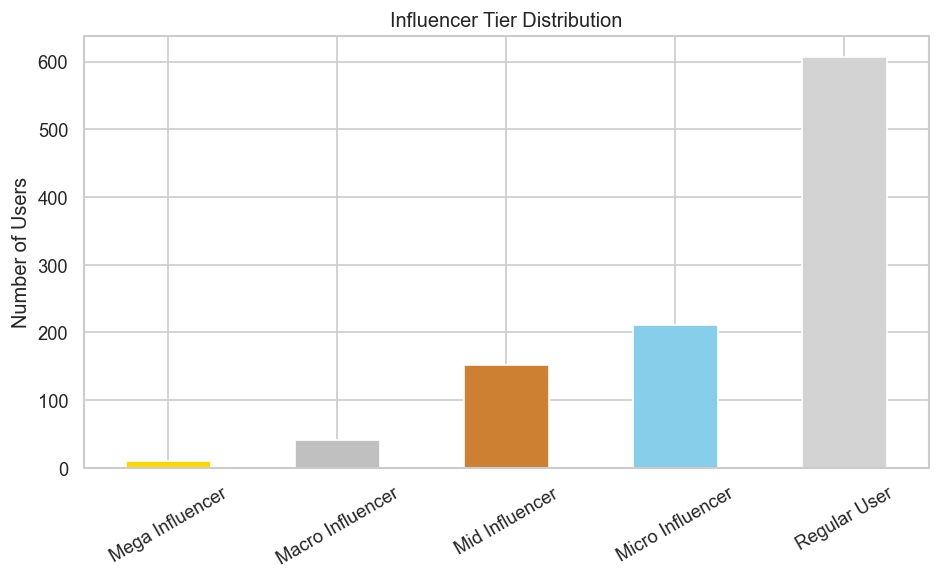

In [ ]:
# ── Tier Assignment ────────────────────────────────────────────────────────────
# Tier Definitions (by percentile):
#   Tier 1 — Mega Influencer  : Top 1%
#   Tier 2 — Macro Influencer : Top 5% (excl T1)
#   Tier 3 — Mid Influencer   : Top 20% (excl T2)
#   Tier 4 — Micro Influencer : Top 50% (excl T3)
#   Tier 5 — Regular User     : Bottom 50%

def assign_tier(percentile):
    if pd.isna(percentile):
        return 5  # default ke Regular kalau kosong
    if percentile >= 99:
        return 1
    elif percentile >= 95:
        return 2
    elif percentile >= 80:
        return 3
    elif percentile >= 50:
        return 4
    else:
        return 5


TIER_LABELS = {
    1: 'Mega Influencer',
    2: 'Macro Influencer',
    3: 'Mid Influencer',
    4: 'Micro Influencer',
    5: 'Regular User'
}

# Apply tier
centrality_df['tier'] = centrality_df['influence_percentile'].apply(assign_tier)
centrality_df['tier_label'] = centrality_df['tier'].map(TIER_LABELS)

# ── Distribution ───────────────────────────────────────────────────────────────
tier_counts = centrality_df['tier_label'].value_counts()

print('Influencer Tier Distribution:')
print(tier_counts.to_string())

# ── Visualization ─────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 5))

tier_order = list(TIER_LABELS.values())
tier_colors = ['#FFD700', '#C0C0C0', '#CD7F32', '#87CEEB', '#D3D3D3']

tier_counts.reindex(tier_order, fill_value=0).plot(
    kind='bar',
    ax=ax,
    color=tier_colors,
    edgecolor='white'
)

ax.set_title('Influencer Tier Distribution')
ax.set_xlabel('')
ax.set_ylabel('Number of Users')
ax.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('../data/processed/sna_tier_distribution.png', bbox_inches='tight', dpi=300)
plt.show()

In [ ]:
# ── Business Question Matrix ───────────────────────────────────────────────

print('=' * 65)
print('  Q: Siapa influencer utama? (Combined Influence)')
print('=' * 65)

cols = [
    'username',
    'tier',
    'in_degree',
    'pagerank',
    'influence_score'
]

cols = [c for c in cols if c in centrality_df.columns]

print(
    centrality_df
    .sort_values('influence_score', ascending=False)
    [cols]
    .head(10)
    .to_string(index=False)
)


print()
print('=' * 65)
print('  Q: Siapa broker antar komunitas? (Betweenness)')
print('=' * 65)

cols = [
    'username',
    'tier',
    'betweenness',
    'in_degree',
    'influence_score'
]

cols = [c for c in cols if c in centrality_df.columns]

print(
    centrality_df
    .sort_values('betweenness', ascending=False)
    [cols]
    .head(10)
    .to_string(index=False)
)


print()
print('=' * 65)
print('  Q: Siapa yang paling aktif komentar? (Out-degree)')
print('=' * 65)

cols = [
    'username',
    'tier',
    'out_degree',
    'in_degree',
    'influence_score'
]

cols = [c for c in cols if c in centrality_df.columns]

print(
    centrality_df
    .sort_values('out_degree', ascending=False)
    [cols]
    .head(10)
    .to_string(index=False)
)

  Q: Siapa influencer utama? (Combined Influence)
                   username  tier  in_degree  pagerank  influence_score
                  sindonews     1         78  0.037869         0.637674
                bitorexpost     1         38  0.018919         0.470147
                 otoproject     1         38  0.018893         0.285348
                    prabowo     1          7  0.001537         0.275700
            investordailyid     1         19  0.009309         0.272257
                tututata151     1          0  0.000573         0.234800
merchandise_original_persib     1          0  0.000573         0.226060
               indo.flashid     1          4  0.001698         0.217921
                    metrotv     1         31  0.015672         0.217059
                luarbioskop     1         29  0.014407         0.200047

  Q: Siapa broker antar komunitas? (Betweenness)
                   username  tier  betweenness  in_degree  influence_score
                    prabowo     1


#### Community Detection (Louvain)

In [ ]:
# ── Louvain Community Detection ────────────────────────────────────────────────
# Why Louvain?
#   - Best modularity optimization algorithm
#   - O(n log n) time complexity → scalable
#   - Handles weighted graphs
#   - Industry standard for social network communities

import community as community_louvain
import pandas as pd

print('Running Louvain community detection...')

# Safety check: graph kosong atau tidak
if G_undirected.number_of_nodes() == 0:
    raise ValueError("Graph is empty. Cannot run community detection.")

# Run Louvain
partition = community_louvain.best_partition(
    G_undirected,
    weight='weight',
    random_state=42
)

# Basic stats
n_communities = len(set(partition.values()))

try:
    modularity = community_louvain.modularity(
        partition,
        G_undirected,
        weight='weight'
    )
except:
    modularity = None

print(f'Communities detected : {n_communities}')
if modularity is not None:
    print(f'Modularity score     : {modularity:.4f}')
    print(f'  (Good modularity: > 0.3, Excellent: > 0.5)')
else:
    print('Modularity score     : could not be computed')

# ── Add community to centrality df ─────────────────────────────────────────────
centrality_df['community_id'] = centrality_df['username'].map(partition)

# Handle node yang nggak masuk graph (kalau ada)
centrality_df['community_id'] = centrality_df['community_id'].fillna(-1).astype(int)

# ── Community sizes ────────────────────────────────────────────────────────────
community_sizes = (
    pd.Series(partition)
    .value_counts()
    .sort_values(ascending=False)
)

print('\nTop community sizes:')
print(community_sizes.head(20).to_string())

# Optional: merge size ke dataframe (berguna buat analisis lanjut)
community_size_map = community_sizes.to_dict()
centrality_df['community_size'] = centrality_df['community_id'].map(community_size_map)

print('\n✅ Louvain community detection complete')

Running Louvain community detection...
Communities detected : 122
Modularity score     : 0.9606
  (Good modularity: > 0.3, Excellent: > 0.5)

Top community sizes:
14    82
18    45
55    43
11    40
37    34
8     32
39    29
5     25
33    22
94    22
1     21
13    20
59    20
17    20
47    19
0     16
7     16
44    16
3     15
65    13

✅ Louvain community detection complete


In [ ]:
import json
from collections import Counter

# ── Community Profiling ─────────────────────────────────────────────

community_profiles = []

for comm_id, size in community_sizes.items():

    comm_users = centrality_df[
        centrality_df['community_id'] == comm_id
    ]

    if comm_users.empty:
        continue

    # Top roles
    top_influencer = comm_users.sort_values(
        'influence_score', ascending=False
    ).iloc[0]

    top_broker = comm_users.sort_values(
        'betweenness', ascending=False
    ).iloc[0]

    top_commenter = comm_users.sort_values(
        'out_degree', ascending=False
    ).iloc[0]

    # ── Keyword Extraction ─────────────────────────────
    kw_list = []

    if 'active_keywords' in comm_users.columns:
        for kw_str in comm_users['active_keywords']:
            try:
                parsed = json.loads(str(kw_str))
                if isinstance(parsed, list):
                    kw_list.extend(parsed)
            except:
                continue

    top_keywords = [
        kw for kw, _ in Counter(kw_list).most_common(5)
    ]

    # ── Raw Data Profiling ─────────────────────────────
    comm_posts = (
        df[df['username'].isin(comm_users['username'])]
        if 'username' in df.columns else pd.DataFrame()
    )

    dominant_sentiment = 'unknown'
    dominant_keyword   = 'unknown'

    if len(comm_posts) > 0:

        if 'sentiment_label' in comm_posts.columns:
            dominant_sentiment = (
                comm_posts['sentiment_label']
                .mode().iloc[0]
            )

        if 'keyword' in comm_posts.columns:
            dominant_keyword = (
                comm_posts['keyword']
                .mode().iloc[0]
            )

    # ── Tier Handling (string-based) ───────────────────
    tier1_count = (
        (comm_users['tier'] == 'Mega').sum()
        if 'tier' in comm_users.columns else 0
    )

    tier2_count = (
        (comm_users['tier'] == 'Macro').sum()
        if 'tier' in comm_users.columns else 0
    )

    # ── Build profile ──────────────────────────────────
    community_profiles.append({
        'community_id':        int(comm_id),
        'size':                int(size),

        'top_influencer':      top_influencer['username'],
        'top_influence_score': round(float(top_influencer['influence_score']), 6),

        'top_broker':          top_broker['username'],
        'top_betweenness':     round(float(top_broker['betweenness']), 6),

        'top_commenter':       top_commenter['username'],
        'top_out_degree':      int(top_commenter['out_degree']),

        'avg_influence_score': round(
            float(comm_users['influence_score'].mean()), 6
        ),

        'dominant_sentiment':  dominant_sentiment,
        'dominant_keyword':    dominant_keyword,

        'keyword_diversity':   len(set(kw_list)),
        'top_keywords':        json.dumps(top_keywords),

        'tier1_count':         int(tier1_count),
        'tier2_count':         int(tier2_count),

        'total_posts':         len(comm_posts),
    })

# ── Final DataFrame ─────────────────────────────────────────────

community_profiles_df = (
    pd.DataFrame(community_profiles)
    .sort_values('size', ascending=False)
)

print('Community Profiles (Top 20):')
print(
    community_profiles_df[[
        'community_id',
        'size',
        'top_influencer',
        'top_broker',
        'dominant_keyword',
        'keyword_diversity',
        'tier1_count',
        'tier2_count'
    ]]
    .head(20)
    .to_string(index=False)
)

Community Profiles (Top 20):
 community_id  size     top_influencer         top_broker dominant_keyword  keyword_diversity  tier1_count  tier2_count
           14    82          sindonews          sindonews   ProduksiMinyak                  0            0            0
           18    45         otoproject         otoproject   ProduksiMinyak                  0            0            0
           55    43        tututata151        tututata151   ProduksiMinyak                  0            0            0
           11    40        bitorexpost        bitorexpost   ProduksiMinyak                  0            0            0
           37    34        luarbioskop        luarbioskop   ProduksiMinyak                  0            0            0
            8    32            metrotv            metrotv   ProduksiMinyak                  0            0            0
           39    29    investordailyid    investordailyid   ProduksiMinyak                  0            0            0
           

---
## 7. White Space Analysis

White space = area **under-served** tapi punya potensi tinggi:
1. Keyword dengan engagement tinggi tapi sedikit influencer aktif → *opportunity gap*
2. Keyword dengan sentimen negatif dominan → *unmet needs*
3. Komunitas terisolasi tapi aktif → *untapped audience*


In [ ]:
# ── White Space: Keyword Opportunity ─────────────────────────────────────

whitespace_results = {}

def normalize(series):
    min_v, max_v = series.min(), series.max()
    if max_v == min_v:
        return pd.Series(0.0, index=series.index)
    return (series - min_v) / (max_v - min_v)

if 'keyword' in df.columns:

    # ── Base aggregation ───────────────────────────────────
    kw_analysis = df.groupby('keyword').agg(
        total_posts   = ('username', 'count'),
        unique_users  = ('username', 'nunique'),
        avg_interaction = (
            'total_interaction', 'mean'
        ) if 'total_interaction' in df.columns else ('username', 'count'),
        pct_negative  = (
            'sentiment_label',
            lambda x: (x.str.lower() == 'negative').mean() * 100
        ) if 'sentiment_label' in df.columns else ('username', lambda x: 0),
    ).reset_index()

    # clean numeric
    kw_analysis['avg_interaction'] = kw_analysis['avg_interaction'].fillna(0)

    # ── Interaction efficiency ─────────────────────────────
    kw_analysis['interaction_per_user'] = (
        kw_analysis['avg_interaction'] /
        kw_analysis['unique_users'].clip(lower=1)
    )

    # ── Influencer filter (FIXED) ──────────────────────────
    tier12_users = set(
        centrality_df[
            centrality_df['tier'].isin(['Mega', 'Macro'])
        ]['username']
    )

    influencer_kw = (
        df[df['username'].isin(tier12_users)]
        .groupby('keyword')['username']
        .nunique()
    )

    kw_analysis['influencer_count'] = (
        kw_analysis['keyword']
        .map(influencer_kw)
        .fillna(0)
        .astype(int)
    )

    # ── White space score ─────────────────────────────────
    kw_analysis['whitespace_score'] = (
        normalize(kw_analysis['interaction_per_user']) -
        normalize(kw_analysis['influencer_count'])
    ).clip(lower=0)

    # ── Ranking ───────────────────────────────────────────
    print('Keyword White Space (Top Opportunities):')

    print(
        kw_analysis
        .sort_values('whitespace_score', ascending=False)
        [[
            'keyword',
            'total_posts',
            'unique_users',
            'avg_interaction',
            'interaction_per_user',
            'influencer_count',
            'pct_negative',
            'whitespace_score'
        ]]
        .head(20)
        .to_string(index=False)
    )

    whitespace_results['keyword_analysis'] = kw_analysis.to_dict('records')

else:
    print('⚠️  Kolom keyword tidak tersedia')

Keyword White Space (Top Opportunities):
         keyword  total_posts  unique_users  avg_interaction  interaction_per_user  influencer_count  pct_negative  whitespace_score
  ProduksiMinyak          879           820         1.878271              0.002291                 0     37.656428               1.0
 HargaMinyakBumi            1             1         0.000000              0.000000                 0      0.000000               0.0
     KonsumsiBBM            6             6         0.000000              0.000000                 0      0.000000               0.0
KenaikanhargaBBM           36            26         0.000000              0.000000                 0      8.333333               0.0
    KrisisEnergi          500           399         0.000000              0.000000                 0     28.000000               0.0
 MinyakIndonesia           15            14         0.000000              0.000000                 0      0.000000               0.0
      SubsidiBBM          27

In [ ]:
# ── White Space: Community Isolation ─────────────────────────────────────

isolated_communities = []

for comm_id in community_sizes.index:

    # node dalam komunitas
    comm_nodes = [
        n for n, c in partition.items()
        if c == comm_id
    ]

    if len(comm_nodes) < 2:
        continue

    # subgraph komunitas
    subgraph = G_undirected.subgraph(comm_nodes)

    internal_edges = subgraph.number_of_edges()

    # total edges touching nodes (internal + external)
    total_degree = sum(
        G_undirected.degree(n)
        for n in comm_nodes
    ) / 2

    isolation_ratio = (
        internal_edges / max(total_degree, 1)
    )

    # ambil user dalam komunitas
    comm_users = centrality_df[
        centrality_df['community_id'] == comm_id
    ]

    # avg engagement (optional)
    if 'total_comments_recv' in comm_users.columns:
        avg_recv = (
            comm_users['total_comments_recv']
            .fillna(0)
            .mean()
        )
    else:
        avg_recv = 0

    isolated_communities.append({
        'community_id':    int(comm_id),
        'size':            int(community_sizes[comm_id]),

        'isolation_ratio': round(isolation_ratio, 4),

        'avg_comments_recv': round(avg_recv, 2),

        'is_isolated':     isolation_ratio > 0.85,

        # white space = isolated + masih ada activity
        'is_whitespace':   (
            isolation_ratio > 0.85
            and avg_recv > 0
        )
    })

# ── DataFrame ─────────────────────────────────────────────

isolated_df = pd.DataFrame(isolated_communities)

print(f'Highly isolated communities  : {isolated_df["is_isolated"].sum()}')
print(f'White space communities      : {isolated_df["is_whitespace"].sum()}')
print()

print(
    isolated_df[
        isolated_df['is_whitespace']
    ]
    .sort_values('avg_comments_recv', ascending=False)
    .to_string(index=False)
)

whitespace_results['isolated_communities'] = (
    isolated_df.to_dict('records')
)

Highly isolated communities  : 122
White space communities      : 0

Empty DataFrame
Columns: [community_id, size, isolation_ratio, avg_comments_recv, is_isolated, is_whitespace]
Index: []


In [ ]:
# ── Export 3 graph JSON untuk backend ─────────────────────────────────────

def export_graph(G_dir, G_undir, centrality_df, label, partition, community_profiles_df, whitespace_results, filename):
    """label: 'comment' | 'mention' | 'combined'"""
    
    pr_col = f'{label}_centrality'  # comment_centrality / mention_centrality / combined_centrality
    
    nodes_export = []
    for node in G_dir.nodes():
        row = centrality_df[centrality_df['username'] == node]
        if row.empty:
            continue
        row = row.iloc[0]
        try:
            kw_list = json.loads(str(row.get('active_keywords', '[]')))
        except:
            kw_list = []

        nodes_export.append({
            'id':                   node,
            'username':             node,
            'influence_score':      round(float(row.get('influence_score', 0) or 0), 6),
            'tier':                 int(row.get('tier', 5) or 5),
            'tier_label':           str(row.get('tier_label', 'Regular User')),
            'pagerank':             round(float(row.get(pr_col, 0) or 0), 8),
            'pagerank_comment':     round(float(row.get('comment_centrality', 0) or 0), 8),
            'pagerank_mention':     round(float(row.get('mention_centrality', 0) or 0), 8),
            'pagerank_combined':    round(float(row.get('combined_centrality', 0) or 0), 8),
            'betweenness':          round(float(row.get('betweenness', 0) or 0), 8),
            'in_degree':            int(G_dir.in_degree(node)),
            'out_degree':           int(G_dir.out_degree(node)),
            'total_degree':         int(G_undir.degree(node)) if G_undir.has_node(node) else 0,
            'community_id':         int(row.get('community_id', 0) or 0),
            'active_keywords':      kw_list,
            'graph_type':           label,
        })

    edges_export = [
        {
            'source':    u,
            'target':    v,
            'weight':    round(float(d.get('weight', 1)), 4),
            'edge_type': label,
        }
        for u, v, d in G_dir.edges(data=True)
    ]

    out = {
        'metadata': {
            'total_nodes':   G_dir.number_of_nodes(),
            'total_edges':   G_dir.number_of_edges(),
            'density':       round(nx.density(G_dir), 8),
            'graph_type':    label,
            'modularity':    round(community_louvain.modularity(partition, G_undir, weight='weight'), 6),
            'n_communities': len(set(partition.values())),
        },
        'nodes':       nodes_export,
        'edges':       edges_export,
        'communities': community_profiles_df.to_dict('records'),
        'whitespace':  whitespace_results,
    }

    path = f'../data/processed/graph_data_{label}.json'
    with open(path, 'w') as f:
        json.dump(out, f, default=str, ensure_ascii=False)
    print(f'✅ {path} — {len(nodes_export)} nodes, {len(edges_export)} edges')


# Export semua 3
G_comment_undir  = G_comment.to_undirected()
G_mention_undir  = G_mention.to_undirected()
G_combined_undir = G_combined.to_undirected()

export_graph(G_comment,  G_comment_undir,  centrality_df, 'comment',  partition, community_profiles_df, whitespace_results, 'graph_data_comment.json')
export_graph(G_mention,  G_mention_undir,  centrality_df, 'mention',  partition, community_profiles_df, whitespace_results, 'graph_data_mention.json')
export_graph(G_combined, G_combined_undir, centrality_df, 'combined', partition, community_profiles_df, whitespace_results, 'graph_data_combined.json')

✅ ../data/processed/graph_data_comment.json — 931 nodes, 823 edges
✅ ../data/processed/graph_data_mention.json — 134 nodes, 99 edges
✅ ../data/processed/graph_data_combined.json — 1022 nodes, 919 edges


---
## 8. Export untuk Backend API

Format: **node-link JSON** compatible dengan D3.js / react-force-graph / sigma.js

Setiap node include `active_keywords` → dipakai untuk filter & warna di website UI.


In [ ]:
# ── Pyvis Interactive Preview ────────────────────────────────────────────────
top_nodes = (
    centrality_df
    .sort_values('influence_score', ascending=False)
    .head(TOP_N_NODES_VIZ)['username']
    .tolist()
)
G_viz = G_undirected.subgraph(top_nodes).copy()

COMMUNITY_COLORS = [
    '#E74C3C','#3498DB','#2ECC71','#F39C12','#9B59B6',
    '#1ABC9C','#E67E22','#34495E','#F1C40F','#16A085',
    '#8E44AD','#27AE60','#D35400','#2980B9','#C0392B',
    '#A93226','#148F77','#B7950B','#6C3483','#117A65',
]

net = Network(
    height='750px', width='100%',
    bgcolor='#1a1a2e', font_color='white',
    directed=False,
)
net.barnes_hut(
    gravity=-8000, central_gravity=0.3,
    spring_length=100, spring_strength=0.05,
)

for node in G_viz.nodes():
    row = centrality_df[centrality_df['username'] == node]
    if row.empty:
        continue
    row     = row.iloc[0]
    comm_id = int(row.get('community_id', 0) or 0)
    tier    = int(row.get('tier', 5) or 5)
    size    = 8 + float(row.get('influence_score', 0) or 0) * 60
    color   = COMMUNITY_COLORS[comm_id % len(COMMUNITY_COLORS)]

    try:
        kw_display = ', '.join(json.loads(str(row.get('active_keywords', '[]')))[:5])
    except Exception:
        kw_display = ''

    title = (
        f"<b>@{node}</b><br>"
        f"Tier            : {row.get('tier_label', '?')}<br>"
        f"Influence Score : {row.get('influence_score', 0):.4f}<br>"
        f"PageRank        : {row.get('pagerank', 0):.6f}<br>"
        f"Betweenness     : {row.get('betweenness_centrality', 0):.6f}<br>"
        f"In-degree       : {int(row.get('in_degree', 0) or 0)}<br>"
        f"Out-degree      : {int(row.get('out_degree', 0) or 0)}<br>"
        f"Comments recv   : {int(row.get('total_comments_recv', 0) or 0):,}<br>"
        f"Posts           : {int(row.get('post_count', 0) or 0)}<br>"
        f"Community       : #{comm_id}<br>"
        f"Keywords        : {kw_display}"
    )

    net.add_node(
        node,
        label=node if tier <= 3 else '',
        title=title,
        size=max(size, 5),
        color=color,
        borderWidth=3 if tier == 1 else (2 if tier == 2 else 1),
        borderWidthSelected=5,
    )

for u, v, data in G_viz.edges(data=True):
    net.add_edge(u, v,
                 value=min(float(data.get('weight', 1)), 10),
                 color='rgba(255,255,255,0.08)')

viz_path = '../data/processed/network_visualization.html'
net.save_graph(viz_path)
print(f'✅ Pyvis saved: {viz_path}')
print(f'   Nodes: {G_viz.number_of_nodes():,}  Edges: {G_viz.number_of_edges():,}')

✅ Pyvis saved: ../data/processed/network_visualization.html
   Nodes: 500  Edges: 390


In [ ]:
# ── Export JSON untuk Backend ────────────────────────────────────────────────
nodes_export = []
for node in G_directed.nodes():
    row = centrality_df[centrality_df['username'] == node]
    if row.empty:
        continue
    row = row.iloc[0]

    try:
        kw_list = json.loads(str(row.get('active_keywords', '[]')))
    except Exception:
        kw_list = []

    nodes_export.append({
        'id':                  node,
        'username':            node,
        # Influence
        'influence_score':     round(float(row.get('influence_score', 0) or 0), 6),
        'tier':                int(row.get('tier', 5) or 5),
        'tier_label':          str(row.get('tier_label', 'Regular User')),
        # Centrality
        'pagerank':            round(float(row.get('pagerank', 0) or 0), 8),
        'betweenness':         round(float(row.get('betweenness_centrality', 0) or 0), 8),
        'closeness':           round(float(row.get('closeness_centrality', 0) or 0), 8),
        'eigenvector':         round(float(row.get('eigenvector_centrality', 0) or 0), 8),
        'authority_score':     round(float(row.get('authority_score', 0) or 0), 8),
        'hub_score':           round(float(row.get('hub_score', 0) or 0), 8),
        # Degree
        'in_degree':           int(row.get('in_degree', 0) or 0),
        'out_degree':          int(row.get('out_degree', 0) or 0),
        'total_degree':        int(row.get('total_degree', 0) or 0),
        # Content metrics
        'post_count':          int(row.get('post_count', 0) or 0),
        'total_comments_recv': int(row.get('total_comments_recv', 0) or 0),
        'total_interaction':   float(row.get('total_interaction', 0) or 0),
        'avg_interaction':     round(float(row.get('avg_interaction', 0) or 0), 2),
        'total_post_like':     float(row.get('total_post_like', 0) or 0),
        # Community
        'community_id':        int(row.get('community_id', 0) or 0),
        # Keywords → filter & warna di website
        'active_keywords':     kw_list,
    })

edges_export = []
for u, v, data in G_directed.edges(data=True):
    edges_export.append({
        'source':    u,
        'target':    v,
        'weight':    round(float(data.get('weight', 1)), 4),
        'edge_type': str(data.get('edge_type', 'comment')),
    })

edge_type_counts = Counter(e['edge_type'] for e in edges_export)

graph_data = {
    'metadata': {
        'total_nodes':       G_directed.number_of_nodes(),
        'total_edges':       G_directed.number_of_edges(),
        'density':           round(nx.density(G_directed), 8),
        'modularity':        round(modularity, 6),
        'n_communities':     n_communities,
        'lcc_ratio':         round(lcc_ratio, 4),
        'edge_architecture': 'comment-on-post (PRIMARY) + mention (LAYER 2)',
        'edge_type_counts':  dict(edge_type_counts),
    },
    'nodes':       nodes_export,
    'edges':       edges_export,
    'communities': community_profiles_df.to_dict('records'),
    'whitespace':  whitespace_results,
}

with open('../data/processed/graph_data.json', 'w') as f:
    json.dump(graph_data, f, default=str, ensure_ascii=False)

print('✅ graph_data.json exported')
print(f'   Nodes : {len(nodes_export):,}')
print(f'   Edges : {len(edges_export):,}')

✅ graph_data.json exported
   Nodes : 1,022
   Edges : 919


In [ ]:
# ── Export CSV ───────────────────────────────────────────────────────────────
export_cols = [
    'username', 'influence_score', 'influence_percentile', 'tier', 'tier_label',
    'community_id',
    'in_degree', 'out_degree', 'total_degree',
    'in_degree_centrality', 'out_degree_centrality',
    'pagerank', 'betweenness_centrality', 'closeness_centrality',
    'eigenvector_centrality', 'authority_score', 'hub_score',
    'post_count', 'total_comments_recv', 'total_interaction',
    'avg_interaction', 'total_post_like', 'active_keywords',
]
export_cols = [c for c in export_cols if c in centrality_df.columns]

(
    centrality_df
    .sort_values('influence_score', ascending=False)
    [export_cols]
    .to_csv('../data/processed/influencer_ranking.csv', index=False)
)
community_profiles_df.to_csv('../data/processed/community_profiles.csv', index=False)

print('✅ Exports:')
print(f'   influencer_ranking.csv  ({len(centrality_df):,} users)')
print(f'   community_profiles.csv  ({len(community_profiles_df):,} communities)')
print(f'   graph_data.json')
print(f'   network_visualization.html')

✅ Exports:
   influencer_ranking.csv  (1,022 users)
   community_profiles.csv  (122 communities)
   graph_data.json
   network_visualization.html


In [ ]:
# ── Final Summary ────────────────────────────────────────────────────────────
print('''
╔══════════════════════════════════════════════════════════════════╗
║                  SNA ANALYSIS COMPLETE ✅                        ║
╚══════════════════════════════════════════════════════════════════╝
''')
print(f'  Nodes              : {G_directed.number_of_nodes():,}')
print(f'  Edges              : {G_directed.number_of_edges():,}')
print(f'  Edge architecture  : comment-on-post (weight = comment_count)')
print(f'  Communities        : {n_communities}')
print(f'  Modularity         : {modularity:.4f}')
print()
for tier_id, label in TIER_LABELS.items():
    cnt = (centrality_df['tier'] == tier_id).sum()
    print(f'  Tier {tier_id} ({label:22s}): {cnt:,}')
print()
print('  OUTPUTS:')
print('  • graph_data.json             → D3 / react-force-graph ready')
print('  • influencer_ranking.csv      → per-user centrality + tier + keywords')
print('  • community_profiles.csv      → community summary')
print('  • network_visualization.html  → Pyvis preview')
print()
print('  node.active_keywords → pakai untuk filter & warna di website UI')
print('  node.in_degree       → proxy total komentar diterima')
print('  node.betweenness     → broker score untuk brand outreach')


╔══════════════════════════════════════════════════════════════════╗
║                  SNA ANALYSIS COMPLETE ✅                        ║
╚══════════════════════════════════════════════════════════════════╝

  Nodes              : 1,022
  Edges              : 919
  Edge architecture  : comment-on-post (weight = comment_count)
  Communities        : 122
  Modularity         : 0.9606

  Tier 1 (Mega Influencer       ): 11
  Tier 2 (Macro Influencer      ): 41
  Tier 3 (Mid Influencer        ): 152
  Tier 4 (Micro Influencer      ): 211
  Tier 5 (Regular User          ): 607

  OUTPUTS:
  • graph_data.json             → D3 / react-force-graph ready
  • influencer_ranking.csv      → per-user centrality + tier + keywords
  • community_profiles.csv      → community summary
  • network_visualization.html  → Pyvis preview

  node.active_keywords → pakai untuk filter & warna di website UI
  node.in_degree       → proxy total komentar diterima
  node.betweenness     → broker score untuk brand ou